In [200]:
print("all ok")

all ok


In [1]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [61]:
model="meta-llama/llama-4-maverick-17b-128e-instruct"

### Load the model

In [4]:
model="meta-llama/llama-4-maverick-17b-128e-instruct"
from langchain_groq import ChatGroq
llm=ChatGroq(model_name=model)
llm.invoke("hi")

AIMessage(content='Hello! How are you today? Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 11, 'total_tokens': 34, 'completion_time': 0.02852216, 'prompt_time': 0.000166488, 'queue_time': 0.051569991, 'total_time': 0.028688648}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--ed1d0b5d-7eb3-4c67-97cf-67322a4afee8-0', usage_metadata={'input_tokens': 11, 'output_tokens': 23, 'total_tokens': 34})

In [5]:
llm=ChatGroq(model_name=model)

In [6]:
llm.invoke("hi")

AIMessage(content='hi how can i help you?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 11, 'total_tokens': 19, 'completion_time': 0.039558177, 'prompt_time': 0.000182907, 'queue_time': 0.048132783, 'total_time': 0.039741084}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--18e87250-39b4-4407-8039-9d9003605eed-0', usage_metadata={'input_tokens': 11, 'output_tokens': 8, 'total_tokens': 19})

In [7]:
print(llm.invoke("hi").content)

Hi! How are you today? Is there something I can help you with or would you like to chat?


In [62]:
import operator
from typing import List
from langgraph.graph.message import add_messages
from pydantic import BaseModel , Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [9]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [154]:
# HumanMessage("hi how are you?")

In [155]:
# HumanMessage(["hi how are you?"])

### this code is only for the testing

In [10]:

state={"messages":["hi hello how are you?"]}
call_model(state)

{'messages': [AIMessage(content="Hello! I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 16, 'total_tokens': 63, 'completion_time': 0.071235369, 'prompt_time': 0.715605115, 'queue_time': 0.832727471, 'total_time': 0.786840484}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_9b0c2006ef', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--6c143b4b-f093-4beb-be24-d76dc47b1d77-0', usage_metadata={'input_tokens': 16, 'output_tokens': 47, 'total_tokens': 63})]}

In [11]:
from langchain_core.messages import AnyMessage
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

NameError: name 'TypedDict' is not defined

## Design a simple workflow without tool calling/

In [12]:
workflow=StateGraph(MessagesState)

In [13]:
workflow.add_node("mybot",call_model)

In [14]:
workflow.add_edge(START,"mybot")

In [15]:
workflow.add_edge("mybot",END)

In [16]:
app=workflow.compile()

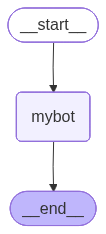

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [18]:
input={"messages":["hi hello how are you?"]}

In [19]:
app.invoke(input)

{'messages': [HumanMessage(content='hi hello how are you?', additional_kwargs={}, response_metadata={}, id='747881fd-aaba-46c9-b1ab-e61e7c29c422'),
  AIMessage(content="Hello! I'm just a language model, I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 16, 'total_tokens': 52, 'completion_time': 0.037961907, 'prompt_time': 0.000326776, 'queue_time': 0.120022094, 'total_time': 0.038288683}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--544de6b8-062f-4d7e-8562-fe2f2dcfe0b9-0', usage_metadata={'input_tokens': 16, 'output_tokens': 36, 'total_tokens': 52})]}

In [20]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from mybot Node
_______
{'messages': [AIMessage(content="Hello! I'm just a language model, I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you have. How about you? How's your day going?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 16, 'total_tokens': 61, 'completion_time': 0.048002997, 'prompt_time': 0.000509683, 'queue_time': 0.050603707, 'total_time': 0.04851268}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--89150664-fe54-42c9-bc96-42e41a647d5c-0', usage_metadata={'input_tokens': 16, 'output_tokens': 45, 'total_tokens': 61})]}




### this is a workflow with tool calling

In [21]:
@tool
def search(query:str):
    """this is my custom tool for searching a weather"""
    if "delhi" in query.lower():
        return "the temp is 45 degree and sunny"
    return "the temp is 25 degree and cloudy"

## testing a tool

In [22]:
search.invoke("what is a tempurature in kashmir?")

'the temp is 25 degree and cloudy'

In [23]:
search.invoke("what is a tempurature in delhi?")

'the temp is 45 degree and sunny'

In [24]:
search

StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000012A3D291DA0>)

In [25]:
llm.invoke("what is a weather in delhi?")

AIMessage(content="Delhi, the capital city of India, experiences a diverse range of weather conditions throughout the year due to its geographical location. The climate is characterized as a humid subtropical climate with significant variations between summer and winter. Here's an overview of the typical weather conditions in Delhi throughout the year:\n\n1. **Summer (April to June):** Summers in Delhi are extremely hot, with temperatures often soaring above 40°C (104°F). May and June are usually the hottest months, with average highs around 42-45°C (108-113°F). The heat is accompanied by dry winds, making the heat feel even more intense.\n\n2. **Monsoon (July to September):** The monsoon season brings relief from the scorching heat. Delhi receives the majority of its annual rainfall during these months, with July and August being the wettest. The rain is crucial for cooling down the city and replenishing water sources, but it can also lead to waterlogging and traffic disruptions in so

### Binding a tool to the LLM

### Special Note: use some good for agentic workflow since opensource model might not give you the correct output

In [26]:
tools=[search]

In [27]:
llm_with_tool=llm.bind_tools(tools)

### testig my llm_with_tool

In [28]:
response=llm_with_tool.invoke("what is a weather is delhi?")

In [29]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1s8jtaa53', 'function': {'arguments': '{"query":"delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 715, 'total_tokens': 745, 'completion_time': 0.039818134, 'prompt_time': 0.018646944, 'queue_time': 0.474366425, 'total_time': 0.058465078}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_9b0c2006ef', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b0dd06ee-74f4-471a-aead-ea8687381737-0', tool_calls=[{'name': 'search', 'args': {'query': 'delhi weather'}, 'id': '1s8jtaa53', 'type': 'tool_call'}], usage_metadata={'input_tokens': 715, 'output_tokens': 30, 'total_tokens': 745})

In [30]:
response.content

''

In [31]:
response.tool_calls

[{'name': 'search',
  'args': {'query': 'delhi weather'},
  'id': '1s8jtaa53',
  'type': 'tool_call'}]

In [32]:
def call_model(state:MessagesState):
    question=state["messages"]
    response=llm_with_tool.invoke(question)
    return {"messages":[response]}

### Testing code

In [33]:
input={"messages":["what is a weather in delhi?"]}

In [34]:
response=call_model(input)

In [35]:
response["messages"][-1].content

''

In [36]:
response["messages"][-1].tool_calls

[{'name': 'search',
  'args': {'query': 'delhi weather'},
  'id': 'fyb6h801h',
  'type': 'tool_call'}]

### here my router function

#### now whatever will come from call_model router funtion will redirect this to the appropriate tool

In [37]:
def router_function(state:MessagesState):
    message=state["messages"]
    last_message=message[-1]
    if last_message.tool_calls:
        return "tools"
    return END
    

In [38]:
tools

[StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000012A3D291DA0>)]

In [39]:

tool_node=ToolNode(tools)

In [40]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'store': ('store', None)}, tools_by_name={'search': StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000012A3D291DA0>)}, tool_to_state_args={'search': {}}, tool_to_store_arg={'search': None}, handle_tool_errors=True, messages_key='messages')

In [41]:
workflow2=StateGraph(MessagesState)

In [42]:
workflow2.add_node("llmwithtool",call_model)

workflow2.add_node("mytools",tool_node)

workflow2.add_edge(START,"llmwithtool")

workflow2.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})

In [43]:
app2=workflow2.compile()

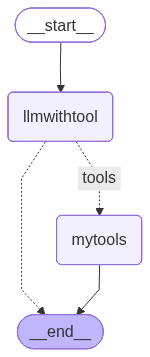

In [44]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [45]:
response=app2.invoke({"messages":["what is a weather in bengraluru?"]})

In [46]:
response["messages"][-1].content

'the temp is 25 degree and cloudy'

In [47]:
app2.invoke({"messages":["what is a weather in delhi?"]})

{'messages': [HumanMessage(content='what is a weather in delhi?', additional_kwargs={}, response_metadata={}, id='0bb25f86-88ea-4adf-a925-0f72ddf961c6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zdsjc9k3k', 'function': {'arguments': '{"query":"delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 715, 'total_tokens': 745, 'completion_time': 0.043924689, 'prompt_time': 0.015812014, 'queue_time': 0.048549465, 'total_time': 0.059736703}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--58a6352d-cf50-48df-8d1f-eb2d8c68b005-0', tool_calls=[{'name': 'search', 'args': {'query': 'delhi weather'}, 'id': 'zdsjc9k3k', 'type': 'tool_call'}], usage_metadata={'input_tokens': 715, 'output_tokens': 30, 'total_tokens': 745}),
  ToolMessage(content='the temp 

### use good resoning based model

In [48]:
app2.invoke({"messages":["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='69d2a9da-7d97-497e-9773-bddb3795bf4b'),
  AIMessage(content="I'm doing well, thank you for asking! I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 712, 'total_tokens': 756, 'completion_time': 0.065067784, 'prompt_time': 0.016683143, 'queue_time': 0.051230996, 'total_time': 0.081750927}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--770fd4ed-605e-48ef-9312-38a6e8125762-0', usage_metadata={'input_tokens': 712, 'output_tokens': 44, 'total_tokens': 756})]}

In [49]:
workflow2.add_edge("mytools","llmwithtool")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [50]:
app3=workflow2.compile()

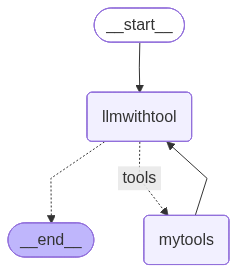

In [51]:
from IPython.display import Image, display
display(Image(app3.get_graph().draw_mermaid_png()))

In [52]:
for output in app3.stream({"messages":["what is a weather in new delhi?"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")
    

here is output from llmwithtool
_______
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'srhd9j0nh', 'function': {'arguments': '{"query":"New Delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 716, 'total_tokens': 746, 'completion_time': 0.049378249, 'prompt_time': 0.015075583, 'queue_time': 0.052640357, 'total_time': 0.064453832}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--6c4a47cc-0bd0-4021-a1dc-2e96dac34faf-0', tool_calls=[{'name': 'search', 'args': {'query': 'New Delhi weather'}, 'id': 'srhd9j0nh', 'type': 'tool_call'}], usage_metadata={'input_tokens': 716, 'output_tokens': 30, 'total_tokens': 746})]}


here is output from mytools
_______
{'messages': [ToolMessage(content='the temp is 45 degree and sunny', name='search', id=

In [53]:
from langgraph.checkpoint.memory import MemorySaver

In [54]:
memory=MemorySaver()

In [55]:
workflow3=StateGraph(MessagesState)

workflow3.add_node("llmwithtool",call_model)

workflow3.add_node("mytools",tool_node)

workflow3.add_edge(START,"llmwithtool")

workflow3.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})

workflow3.add_edge("mytools","llmwithtool")

In [56]:
app4=workflow3.compile(checkpointer=memory)

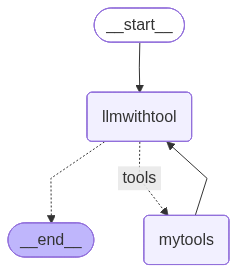

In [57]:
from IPython.display import Image, display
display(Image(app4.get_graph().draw_mermaid_png()))

In [58]:
config={"configurable": {"thread_id": "1"}}

In [59]:
events=app4.stream(
    {"messages":["what is a weather in new delhi?"]},config=config,stream_mode="values"
    )

In [60]:
for event in events:
    event["messages"][-1].pretty_print()
    

================================ Human Message =================================

what is a weather in new delhi?
================================== Ai Message ==================================
Tool Calls:
  search (c4wxwfadk)
 Call ID: c4wxwfadk
  Args:
    query: new delhi weather
================================= Tool Message =================================
Name: search

the temp is 45 degree and sunny
================================== Ai Message ==================================

The temperature in New Delhi is 45 degrees and it's sunny.


In [192]:
events=app4.stream(
    {"messages":["what is a weather in indore?"]},config=config,stream_mode="values"
    )

In [193]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is a weather in indore?
================================== Ai Message ==================================
Tool Calls:
  search (974yyz4yc)
 Call ID: 974yyz4yc
  Args:
    query: weather in Indore
================================= Tool Message =================================
Name: search

the temp is 25 degree and cloudy
================================== Ai Message ==================================
Tool Calls:
  search (z98ty8y88)
 Call ID: z98ty8y88
  Args:
    query: weather in Indore
================================= Tool Message =================================
Name: search

the temp is 25 degree and cloudy
================================== Ai Message ==================================
Tool Calls:
  search (cv0da6bnz)
 Call ID: cv0da6bnz
  Args:
    query: weather in Indore
================================= Tool Message =================================
Name: search

the temp is 25 degree and

In [195]:
config

{'configurable': {'thread_id': '1'}}

In [196]:
memory.get(config)

{'v': 3,
 'ts': '2025-06-14T05:39:36.437057+00:00',
 'id': '1f048e1f-5098-6c90-800c-546d9dcac742',
 'channel_versions': {'__start__': '00000000000000000000000000000007.0.9999317854783963',
  'messages': '00000000000000000000000000000014.0.05050170024719669',
  'branch:to:llmwithtool': '00000000000000000000000000000014.0.8950158264402875',
  'branch:to:mytools': '00000000000000000000000000000013.0.9761122505314639'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000006.0.1517309311235916'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000013.0.778145138763228'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000012.0.7239732522974757'}},
 'channel_values': {'messages': [HumanMessage(content='what is a weather in new delhi?', additional_kwargs={}, response_metadata={}, id='e4d2735a-46f0-46c0-b33f-81d443eb29ff'),
   AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'xjznn9vkf', 'function': {

In [197]:
events=app4.stream(
    {"messages":["in which city the temp was 25 degree?"]},config=config,stream_mode="values"
    )

In [198]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

in which city the temp was 25 degree?
================================== Ai Message ==================================

The city where the temperature was 25 degrees is **Indore**.


In [199]:
memory.get(config)

{'v': 3,
 'ts': '2025-06-14T05:43:58.859647+00:00',
 'id': '1f048e29-1740-6efe-800f-e46aa6319ec4',
 'channel_versions': {'__start__': '00000000000000000000000000000016.0.4268705610643684',
  'messages': '00000000000000000000000000000017.0.702509649584532',
  'branch:to:llmwithtool': '00000000000000000000000000000017.0.41532138018550335',
  'branch:to:mytools': '00000000000000000000000000000013.0.9761122505314639'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000015.0.6664132989990882'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000016.0.5325683866610978'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000012.0.7239732522974757'}},
 'channel_values': {'messages': [HumanMessage(content='what is a weather in new delhi?', additional_kwargs={}, response_metadata={}, id='e4d2735a-46f0-46c0-b33f-81d443eb29ff'),
   AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'xjznn9vkf', 'function': {